# Numerical Integration 2

## Overview

- **Purpose**: Numerically solve ordinary differential equations (ODEs) where analytical solutions are difficult or impossible.
- **Importance**: Widely used in physics, engineering, and cosmology for modeling dynamic systems.

## Background on ODEs

- **Ordinary Differential Equation (ODE)**: An equation involving a function and its derivatives.
- **Initial Value Problem (IVP)**:
  $$
  \frac{dy}{dx} = f(y, x), \quad y(x_0) = y_0
  $$
- **Goal**: Find the function \( $y(x)$ \) satisfying the ODE and initial condition.

## Euler's Method Recap

- **Simplest Numerical Method**:
  $$
  y_{n+1} = y_n + h f(y_n, x_n)
  $$
- **Step Size \( $h$ \)**: The increment in \( $x$ \).
- **Limitations**:
  - Low accuracy (first-order method).
  - Numerical instability with larger step sizes.

## Motivation for Runge-Kutta Methods

- **Need for Improved Accuracy**:
  - Higher-order methods provide better approximations.
- **Runge-Kutta Family**:
  - Includes methods of various orders.
  - **Fourth-Order Runge-Kutta (RK4)** is the most commonly used.


## The Runge-Kutta Method (RK4)

- **Idea**: Compute intermediate slopes to estimate the next value.
- **Uses Four Evaluations** of \( $f(y, x)$ \) per step:
  - \( $k_1$ \): Slope at the beginning of the interval.
  - \( $k_2$ \): Slope at the midpoint using \( $k_1$ \).
  - \( $k_3$ \): Slope at the midpoint using \( $k_2$ \).
  - \( $k_4$ \): Slope at the end using \( $k_3$ \).


## The RK4 Formula

For each step from \( $x_n$ \) to \( $x_{n+1} = x_n + h$ \):

$$
\begin{aligned}
k_1 &= f(y_n, x_n) \\
k_2 &= f\left(y_n + \frac{h\,k_1}{2}, x_n + \frac{h}{2}\right) \\
k_3 &= f\left(y_n + \frac{h\,k_2}{2}, x_n + \frac{h}{2}\right) \\
k_4 &= f(y_n + h\,k_3, x_n + h) \\
y_{n+1} &= y_n + \frac{h}{6}(k_1 + 2k_2 + 2k_3 + k_4)
\end{aligned}
$$

## Intuition Behind RK4

- **Weighted Average of Slopes**:
  - Combines slopes at different points to approximate the integral.
- **Improves Accuracy**:
  - Fourth-order accuracy means the error per step is \( $\mathcal{O}(h^5)$ \), and the total accumulated error is \( $\mathcal{O}(h^4)$ \).


## Algorithm Steps

1. **Initialize**:
   - Set initial values \( $x_0$, $y_0$ \).
2. **For Each Step**:
   - Compute \( $k_1$ \) to \( $k_4$ \) using the formulas.
   - Update \( $y_{n+1}$ \) using the weighted average.
   - Increment \( $x_n$ \) by \( $h$ \).
3. **Repeat** until the desired \( $x$ \) range is covered.


![Runge-Kutta_slopes.svg](Runge-Kutta_slopes.svg)

## Example Problem

**ODE**:
$$
\frac{dy}{dx} = -2 x y^2, \quad y(0) = 1
$$

**Analytical Solution**:
$$
y(x) = ?
$$

**Applying RK4 and Euler**:
- Choose a step size \( h \).
- Compute \( $k_1$ \) to \( $k_4$ \) at each step.
- Compare numerical and analytical solutions.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def euler_method(f, Y0, t0, t_end, h):
    """
    Solve system of ODEs dY/dt = f(Y, t) using the Euler method.
    
    Parameters:
        f (function): The function defining the system dY/dt = f(Y, t).
        Y0 (numpy.ndarray): The initial state vector.
        t0 (float): The initial time.
        t_end (float): The end time.
        h (float): The time step size.
        
    Returns:
        t_values (numpy.ndarray): Array of time values.
        Y_values (numpy.ndarray): Array of state vectors at each time step.
    """
    t_values = np.arange(t0, t_end + h, h)
    n_steps = len(t_values)
    n_vars = len(Y0)
    Y_values = np.zeros((n_steps, n_vars))
    Y_values[0] = Y0
    for i in range(n_steps - 1):
        t_i = t_values[i]
        Y_i = Y_values[i]
        Y_values[i + 1] = Y_i + h * f(Y_i, t_i)
    return t_values, Y_values

In [2]:
def runge_kutta(f, Y0, t0, t_end, h):
    """
    Solve system of ODEs dY/dt = f(Y, t) using the RK4 method.
    
    Parameters:
        f (function): The function defining the system dY/dt = f(Y, t).
        Y0 (numpy.ndarray): The initial state vector.
        t0 (float): The initial time.
        t_end (float): The end time.
        h (float): The time step size.
        
    Returns:
        t_values (numpy.ndarray): Array of time values.
        Y_values (numpy.ndarray): Array of state vectors at each time step.
    """
    t_values = np.arange(t0, t_end + h, h)
    n_steps = len(t_values)
    n_vars = len(Y0)
    Y_values = np.zeros((n_steps, n_vars))
    Y_values[0] = Y0
    for i in range(n_steps - 1):
        t_i = t_values[i]
        Y_i = Y_values[i]
        k1 = h * f(Y_i, t_i)
        k2 = h * f(Y_i + k1 / 2, t_i + h / 2)
        k3 = h * f(Y_i + k2 / 2, t_i + h / 2)
        k4 = h * f(Y_i + k3, t_i + h)
        Y_values[i + 1] = Y_i + (k1 + 2 * k2 + 2 * k3 + k4) / 6
    return t_values, Y_values

In [3]:
# Define the system of ODEs
def f(Y, x):
    y = Y
    return -2*x*y**2
# Initial conditions
x0 = 0.0   # Initial x-position
y0 = 1.0   # Initial y-position
Y0 = np.array([y0, 0])
# Integration parameters
x_end = 2.0  # Duration of the simulation
h = 0.01     # Time step size
# Solve the ODE using Euler method
x_vals_euler, Y_vals_euler = euler_method(f, Y0, x0, x_end, h)
# Solve the ODE using Runge-Kutta method
x_vals_rk, Y_vals_rk = runge_kutta(f, Y0, x0, x_end, h)
# Analytical solution
x_analytical = x_vals_rk
Y_analytical = 1/(x_analytical**2+1)

In [5]:
# Plot the solution
plt.figure(figsize=(12, 8))
plt.plot(x_vals_rk, np.abs(Y_vals_rk[:, 0]/Y_analytical-1), label='Runge-Kutta Method', linewidth=2)
plt.plot(x_vals_euler, np.abs(Y_vals_euler[:, 0]/Y_analytical-1), label='Euler Method', alpha=0.7)
plt.xlabel('x')
plt.ylabel('Rel. Difference between Numerical and Analytical Sol.')
plt.title(r'Numerical solution of $\frac{ {\rm d} y}{ {\rm d} x} = -2\,x\,y^2$')
plt.grid(True)
plt.legend()
plt.loglog()
plt.savefig("rk4vseuler.png")
plt.close()

![rk4vseuler.png](rk4vseuler.png)

In [6]:
# Gravitational constant times mass (GM)
GM = 1.0  # In arbitrary units

# Define the system of ODEs
def f(Y, t):
    x, y, vx, vy = Y
    r = np.sqrt(x**2 + y**2)
    ax = -GM * x / r**3
    ay = -GM * y / r**3
    return np.array([vx, vy, ax, ay])

In [7]:
# Initial conditions
x0 = 1.0   # Initial x-position
y0 = 0.0   # Initial y-position
vx0 = -0.8 # Initial x-velocity
vy0 = 0.8  # Initial y-velocity
Y0 = np.array([x0, y0, vx0, vy0])
# Time parameters
t0 = 0.0
t_end = 100.0  # Duration of the simulation
h = 0.001      # Time step size
# Solve the ODE using Euler method
t_vals_euler, Y_vals_euler = euler_method(f, Y0, t0, t_end, h)
x_vals_euler = Y_vals_euler[:, 0]
y_vals_euler = Y_vals_euler[:, 1]
# Solve the ODE using Runge-Kutta method
t_vals_rk, Y_vals_rk = runge_kutta(f, Y0, t0, t_end, h)
x_vals_rk = Y_vals_rk[:, 0]
y_vals_rk = Y_vals_rk[:, 1]

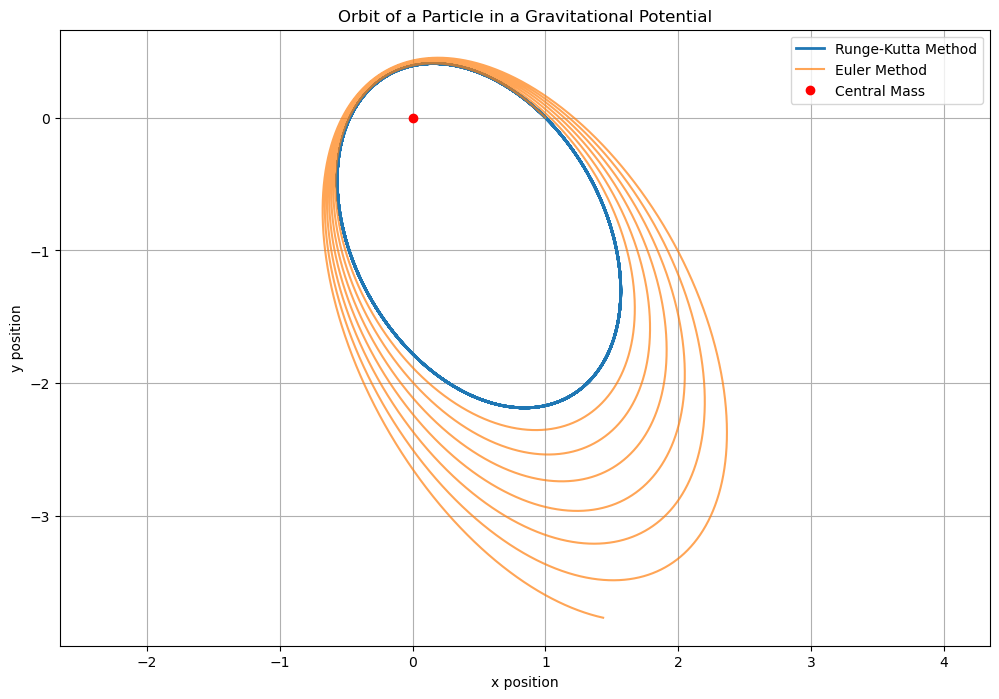

In [8]:
# Plot the orbits
plt.figure(figsize=(12, 8))
plt.plot(x_vals_rk, y_vals_rk, label='Runge-Kutta Method', linewidth=2)
plt.plot(x_vals_euler, y_vals_euler, label='Euler Method', alpha=0.7)
plt.plot(0, 0, 'ro', label='Central Mass')
plt.xlabel('x position')
plt.ylabel('y position')
plt.title('Orbit of a Particle in a Gravitational Potential')
plt.axis('equal')
plt.grid(True)
plt.legend()
plt.savefig('orbit.png')

![orbit.png](orbit.png)

# Introduction to the Leap-Frog Algorithm

## Overview

- **Purpose**: Numerically solve ordinary differential equations (ODEs) for systems in classical mechanics.
- **Application**: Ideal for simulating particles in conservative force fields (e.g., gravitational orbits).
- **Key Feature**: Conserves energy over long simulations due to its symplectic nature.

## Background on Numerical Integration

- **Hamiltonian Systems**:
  - Governed by conservation laws (energy, momentum).
  - Require integrators that preserve these properties.
- **Common Methods**:
  - **Euler Method**: Simple but unstable over long times.
  - **Runge-Kutta Methods**: Accurate but may not conserve energy.
- **Need for Symplectic Integrators**:
  - Preserve the geometric structure of Hamiltonian systems.
  - Maintain long-term stability and energy conservation.


## The Leap-Frog Algorithm

- **Type**: Second-order symplectic integrator.
- **Idea**:
  - Positions and velocities are updated in a staggered (leap-frog) manner.
  - Velocities are computed at half-integer time steps.
  - Positions are computed at integer time steps.
- **Benefits**:
  - Excellent energy conservation.
  - Suitable for long-term simulations.


## Leap-Frog Integration Steps
  
1. **Initialize**:
   - Initial position \( $\mathbf{x}_0$ \).
   - Initial velocity \( $\mathbf{v}_0$ \).

2. **First Half-Step for Velocity**:
   $$
   \mathbf{v}_{1/2} = \mathbf{v}_0 + \frac{h}{2} \mathbf{a}(\mathbf{x}_0, t_0)
   $$

3. **Loop Over Time Steps**:
   - **Update Position**:
     $$
     \mathbf{x}_{n+1} = \mathbf{x}_n + h \mathbf{v}_{n+1/2}
     $$
   - **Compute Acceleration at New Position**:
     $$
     \mathbf{a}_{n+1} = \mathbf{a}(\mathbf{x}_{n+1}, t_{n+1})
     $$
   - **Update Velocity**:
     $$
     \mathbf{v}_{n+3/2} = \mathbf{v}_{n+1/2} + h \mathbf{a}_{n+1}
     $$

4. **Repeat** for desired number of steps.

## Visualization of the Leap-Frog Steps

- **Staggered Updates**:
  - Positions at \( $t_n$ \), \( $t_{n+1}$ \), \( $t_{n+2}$ \).
  - Velocities at \( $t_{n+1/2}$ \), \( $t_{n+3/2}$ \).
- **Leap-Frogging**:
  - Velocities "leap over" positions, and vice versa.
  - This staggered approach leads to better energy conservation.

<div style="text-align: center;">
  <img src="leapfrog.gif" alt="Leapfrog Steps" />
</div>

## Advantages of the Leap-Frog Method

- **Symplectic Integrator**:
  - Preserves the Hamiltonian structure of equations.
- **Energy Conservation**:
  - Total energy remains nearly constant over long times.
- **Stability**:
  - More stable than Euler's method for oscillatory systems.
- **Second-Order Accuracy**:
  - Local truncation error is \( $\mathcal{O}(h^3)$ \).


In [9]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
# Define symbols
h_symbol, omega_symbol = sp.symbols('h omega', real=True, positive=True)
x_n_symbol, v_n_symbol = sp.symbols('x_n v_n', real=True)
# Euler Method
# Acceleration at time n
a_n_symbol = -omega_symbol**2 * x_n_symbol
# Update equations
x_np1_euler = x_n_symbol + h_symbol * v_n_symbol
v_np1_euler = v_n_symbol + h_symbol * a_n_symbol
# Energy at time n
E_n_symbol = 0.5 * v_n_symbol**2 + 0.5 * omega_symbol**2 * x_n_symbol**2
# Energy at time n+1
E_np1_euler = 0.5 * v_np1_euler**2 + 0.5 * omega_symbol**2 * x_np1_euler**2
# Difference in energy
delta_E_euler = E_np1_euler - E_n_symbol
delta_E_euler_simplified = sp.simplify(delta_E_euler)
# Convert to a numerical function
delta_E_euler_func = sp.lambdify((x_n_symbol, v_n_symbol, h_symbol, omega_symbol), delta_E_euler_simplified, 'numpy')
delta_E_euler_simplified

0.5*h**2*omega**2*(omega**2*x_n**2 + v_n**2)

In [10]:
# Runge-Kutta Method (RK2 - Midpoint Method)
# k1 values
k1_v = -h_symbol * omega_symbol**2 * x_n_symbol
k1_x = h_symbol * v_n_symbol
# Midpoint estimates
x_mid = x_n_symbol + 0.5 * k1_x
v_mid = v_n_symbol + 0.5 * k1_v
# k2 values
k2_v = -h_symbol * omega_symbol**2 * x_mid
k2_x = h_symbol * v_mid
# Update positions and velocities
x_np1_rk2 = x_n_symbol + k2_x
v_np1_rk2 = v_n_symbol + k2_v
# Energy at time n+1
E_np1_rk2 = 0.5 * v_np1_rk2**2 + 0.5 * omega_symbol**2 * x_np1_rk2**2
# Difference in energy
delta_E_rk2 = E_np1_rk2 - E_n_symbol
delta_E_rk2_simplified = sp.simplify(delta_E_rk2)
# Convert to a numerical function
delta_E_rk2_func = sp.lambdify((x_n_symbol, v_n_symbol, h_symbol, omega_symbol), delta_E_rk2_simplified, 'numpy')
delta_E_rk2_simplified

0.125*h**4*omega**4*(omega**2*x_n**2 + v_n**2)

In [11]:
# Leap-Frog Method 
# Update position and acc
x_np1_vv = x_n_symbol + h_symbol * v_n_symbol + 0.5 * h_symbol**2 * a_n_symbol
a_np1_symbol_vv = -omega_symbol**2 * x_np1_vv
# Update velocity
v_np1_vv = v_n_symbol + 0.5 * h_symbol * (a_n_symbol + a_np1_symbol_vv)
# Energy at time n+1
E_np1_vv = 0.5 * v_np1_vv**2 + 0.5 * omega_symbol**2 * x_np1_vv**2
# Difference in energy
delta_E_vv = E_np1_vv - E_n_symbol
delta_E_vv_simplified = sp.simplify(delta_E_vv)
# Convert to a numerical function
delta_E_vv_func = sp.lambdify((x_n_symbol, v_n_symbol, h_symbol, omega_symbol), delta_E_vv_simplified, 'numpy')
delta_E_vv_simplified

h**3*omega**4*(0.03125*h**3*omega**4*x_n**2 - 0.125*h**2*omega**2*v_n*x_n - 0.125*h*omega**2*x_n**2 + 0.125*h*v_n**2 + 0.25*v_n*x_n)

In [12]:
# Numerical parameters
omega = 1.0
h = 0.01
N_steps = 100_000
t = np.arange(0, N_steps * h, h)

# Analytical solutions for x and v
x_exact = np.cos(omega * t)
v_exact = -omega * np.sin(omega * t)

# Compute energy differences per step
delta_E_euler_vals = delta_E_euler_func(x_exact[:-1], v_exact[:-1], h, omega)
delta_E_rk2_vals = delta_E_rk2_func(x_exact[:-1], v_exact[:-1], h, omega)
delta_E_vv_vals = delta_E_vv_func(x_exact[:-1], v_exact[:-1], h, omega)

# Time array for plotting (excluding last point)
t_plot = t[:-1]

# Plotting energy differences
plt.figure(figsize=(12, 6))
plt.plot(t_plot, np.abs(delta_E_euler_vals), label='Euler Method')
plt.plot(t_plot, np.abs(delta_E_rk2_vals), label='Runge-Kutta Method (RK2)')
plt.plot(t_plot, np.abs(delta_E_vv_vals), label='Leap-Frog')
plt.xlabel('Time')
plt.ylabel('|Energy Difference per Step ΔE|')
plt.title('Energy Difference per Step for Various Integration Methods')
plt.legend()
plt.grid(True)
plt.loglog()
plt.savefig("dEdt.png")
plt.close()
# Plotting energy differences
plt.figure(figsize=(12, 6))
plt.plot(t_plot, np.abs(np.cumsum(delta_E_euler_vals)), label='Euler Method')
plt.plot(t_plot, np.abs(np.cumsum(delta_E_rk2_vals)), label='Runge-Kutta Method (RK2)')
plt.plot(t_plot, np.abs(np.cumsum(delta_E_vv_vals)), label='Leap-Frog')
plt.xlabel('Time')
plt.ylabel('|Cummulative Energy Difference per Step ΔE|')
plt.title('Energy Cummulative Difference per Step for Various Integration Methods')
plt.legend()
plt.grid(True)
plt.loglog()
plt.savefig("dEdt-cummulative.png")
plt.close()

![dEdt.png](dEdt.png)

![dEdt-cummulative.png](dEdt-cummulative.png)

In [89]:
import numpy as np
import matplotlib.pyplot as plt

def euler_method(f, Y0, t0, t_end, h):
    """
    Solve system of ODEs dY/dt = f(Y, t) using the Euler method.
    """
    t_values = np.arange(t0, t_end + h, h)
    n_steps = len(t_values)
    n_vars = len(Y0)
    Y_values = np.zeros((n_steps, n_vars))
    kinetic_energy = np.zeros(n_steps)
    potential_energy = np.zeros(n_steps)
    Y_values[0] = Y0

    for i in range(n_steps - 1):
        t_i = t_values[i]
        Y_i = Y_values[i]
        Y_values[i + 1] = Y_i + h * f(Y_i, t_i)

        # Compute energies
        x, y, vx, vy = Y_values[i + 1]
        r = np.sqrt(x**2 + y**2)
        kinetic_energy[i + 1] = 0.5 * (vx**2 + vy**2)
        potential_energy[i + 1] = -GM / r

    return t_values, Y_values, kinetic_energy + potential_energy

def runge_kutta(f, Y0, t0, t_end, h):
    """
    Solve system of ODEs dY/dt = f(Y, t) using the RK4 method.
    """
    t_values = np.arange(t0, t_end + h, h)
    n_steps = len(t_values)
    n_vars = len(Y0)
    Y_values = np.zeros((n_steps, n_vars))
    kinetic_energy = np.zeros(n_steps)
    potential_energy = np.zeros(n_steps)
    Y_values[0] = Y0
    # First step energy
    r = np.sqrt(Y0[0]**2 + Y0[1]**2)
    kinetic_energy[0] = 0.5 * (Y0[2]**2 + Y0[3]**2)
    potential_energy[0] = -GM / r

    for i in range(n_steps - 1):
        t_i = t_values[i]
        Y_i = Y_values[i]
        
        k1 = h * f(Y_i, t_i)
        k2 = h * f(Y_i + k1 / 2, t_i + h / 2)
        k3 = h * f(Y_i + k2 / 2, t_i + h / 2)
        k4 = h * f(Y_i + k3, t_i + h)
        
        Y_values[i + 1] = Y_i + (k1 + 2 * k2 + 2 * k3 + k4) / 6

        # Compute energies
        x, y, vx, vy = Y_values[i + 1]
        r = np.sqrt(x**2 + y**2)
        kinetic_energy[i + 1] = 0.5 * (vx**2 + vy**2)
        potential_energy[i + 1] = -GM / r

    return t_values, Y_values, kinetic_energy + potential_energy

def leap_frog(f, Y0, t0, t_end, h):
    """
    Solve system of ODEs using the Leap-Frog method.
    """
    t_values = np.arange(t0, t_end + h, h)
    n_steps = len(t_values)
    n_vars = len(Y0)
    Y_values = np.zeros((n_steps, n_vars))
    kinetic_energy = np.zeros(n_steps)
    potential_energy = np.zeros(n_steps)

    # Initial positions and velocities
    x0, y0, vx0, vy0 = Y0
    Y_values[0] = Y0

    # First half-step for velocities
    accel = f(Y0, t0)
    vx_half = vx0 + 0.5 * h * accel[2]
    vy_half = vy0 + 0.5 * h * accel[3]

    for i in range(n_steps - 1):
        # Update positions
        x_i = Y_values[i, 0] + h * vx_half
        y_i = Y_values[i, 1] + h * vy_half

        # Calculate acceleration at new position
        r = np.sqrt(x_i**2 + y_i**2)
        ax = -GM * x_i / r**3
        ay = -GM * y_i / r**3

        # Update velocities
        vx_half += h * ax
        vy_half += h * ay

        # Store updated positions and velocities
        Y_values[i + 1, 0] = x_i
        Y_values[i + 1, 1] = y_i
        Y_values[i + 1, 2] = vx_half - 0.5 * h * ax  # Full-step velocity
        Y_values[i + 1, 3] = vy_half - 0.5 * h * ay

    r = np.sqrt(Y_values[:, 0]**2 + Y_values[:, 1]**2)
    kinetic_energy = 0.5 * (Y_values[:, 2]**2 + Y_values[:, 3]**2)
    potential_energy = -GM / r

    return t_values, Y_values, kinetic_energy + potential_energy

# Example usage
# Gravitational constant times mass (GM)
GM = 1.0  # In arbitrary units

# Define the system of ODEs
def f(Y, t):
    x, y, vx, vy = Y
    r = np.sqrt(x**2 + y**2)
    ax = -GM * x / r**3
    ay = -GM * y / r**3
    return np.array([vx, vy, ax, ay])

# Initial conditions
x0 = 1.0   # Initial x-position
y0 = 0.0   # Initial y-position
vx0 = 0.0  # Initial x-velocity
vy0 = 1.0  # Initial y-velocity (for circular orbit)
Y0 = np.array([x0, y0, vx0, vy0])

# Time parameters
t0 = 0.0
t_end = 2_000.0  # Duration of the simulation
h = 0.1      # Time step size

# Solve the ODE using Euler method
t_vals_euler, Y_vals_euler, energy_euler = euler_method(f, Y0, t0, t_end, h)
x_vals_euler = Y_vals_euler[:, 0]
y_vals_euler = Y_vals_euler[:, 1]

# Solve the ODE using Runge-Kutta method
t_vals_rk, Y_vals_rk, energy_rk = runge_kutta(f, Y0, t0, t_end, h)
x_vals_rk = Y_vals_rk[:, 0]
y_vals_rk = Y_vals_rk[:, 1]

# Solve the ODE using Leap-Frog method
t_vals_lf, Y_vals_lf, energy_lf = leap_frog(f, Y0, t0, t_end, h)
x_vals_lf = Y_vals_lf[:, 0]
y_vals_lf = Y_vals_lf[:, 1]

# Plot the orbits
plt.figure(figsize=(12, 8))
plt.plot(x_vals_rk, y_vals_rk, label='Runge-Kutta Method', linewidth=2)
plt.plot(x_vals_euler, y_vals_euler, label='Euler Method', alpha=0.7)
plt.plot(x_vals_lf, y_vals_lf, label='Leap-Frog Method', linestyle='--')
plt.plot(0, 0, 'ro', label='Central Mass')
plt.xlabel('x position')
plt.ylabel('y position')
plt.title('Orbit of a Particle in a Gravitational Potential')
plt.axis('equal')
plt.grid(True)
plt.legend()
plt.savefig('orbit+lf.png')
plt.close()

# Plot total energy over time
plt.figure(figsize=(12, 6))
plt.plot(t_vals_euler[1:], energy_euler[1:], label='Euler Method')
plt.plot(t_vals_rk[1:], energy_rk[1:], label='Runge-Kutta Method')
plt.plot(t_vals_lf[1:], energy_lf[1:], label='Leap-Frog Method')
plt.xlabel('Time')
plt.ylabel('Total Energy')
plt.xscale('log')
plt.title('Energy Conservation Comparison')
plt.grid(True)
plt.legend()
plt.savefig('dEdt-orbit.png')
plt.close()

# Plot total energy over time
plt.figure(figsize=(12, 6))
plt.plot(t_vals_rk, energy_rk, label='Runge-Kutta Method')
plt.plot(t_vals_lf, energy_lf, label='Leap-Frog Method')
plt.xscale('log')
plt.xlabel('Time')
plt.ylabel('Total Energy')
plt.title('Energy Conservation Comparison')
plt.grid(True)
plt.legend()
plt.savefig('dEdt-cummulative-orbit.png')
plt.close()

![orbit+lf.png](orbit+lf.png)

![dEdt-orbit.png](dEdt-orbit.png)

![dEdt-cummulative-orbit.png](dEdt-cummulative-orbit.png)

## Comparison with Other Methods

### Euler Method

- **Pros**:
  - Simple to implement.
- **Cons**:
  - First-order accuracy.
  - Poor energy conservation.
  - Unstable for long-term simulations.

### Runge-Kutta Methods

- **Pros**:
  - High accuracy per step.
- **Cons**:
  - Not symplectic.
  - Energy drifts over time.


### Leap-Frog Method

- **Pros**:
  - Good balance between simplicity and stability.
  - Conserves energy.
- **Cons**:
  - Requires initial half-step adjustment.
  - Second-order accuracy (less accurate per step than RK4).

<div>
<img src="Oops.png" alt="alt text" style="width:65%;">
</div>

## Implementation of the Spherical Collapse Model in Dark Energy Cosmologies

### Introduction
- **Reference for the numerical implementation**: Pace et al. 2017 (ArXiv:1708.02477)
- **Spherical Collapse Model**: Analytical tool to study the non-linear evolution of structures in the universe.
- **Key Focus**: Investigate how numerical methods affect the calculation of the linear critical overdensity, \( $\delta_c$ \), which is pivotal for mass functions.

## Numerical Implementations
### **Implementation A**
- Solves a **single second-order differential equation**:
  $$
  \delta'' + \left( 2 + \frac{H'}{H} \right) \delta' - \frac{4}{3} \frac{\delta'^2}{1 + \delta} - \frac{3}{2} \Omega_m(a) \delta(1 + \delta) = 0
  $$
  and its linearized counterpart:
  $$
  \delta'' + \left( 2 + \frac{H'}{H} \right) \delta' - \frac{3}{2} \Omega_m(a) \delta = 0
  $$

### **Implementation B**
- Solves a **system of two first-order differential equations**:
    $$
    \delta_m' + (1 + \delta_m) \theta_m = 0
    $$
    $$
    \theta_m' + \left( 2 + \frac{H'}{H} \right) \theta_m + \frac{\theta_m^2}{3} + \frac{3}{2} \left[ \Omega_m(a) \delta_m + \left( 1 + 3c^2_{\text{eff}} \right) \Omega_{\text{de}}(a) \delta_{\text{de}} \right] = 0
    $$
- At **linear level**:
    $$
    \delta_m' + \theta_m = 0
    $$
    $$
    \theta_m' + \left( 2 + \frac{H'}{H} \right) \theta_m + \frac{3}{2} \left[ \Omega_m(a) \delta_m + \left( 1 + 3c^2_{\text{eff}} \right) \Omega_{\text{de}}(a) \delta_{\text{de}} \right] = 0
    $$

### **Implementation C**
- Reformulates equations using the inverse density contrast \( f = 1 / $\delta$ \):
  - Inverse density evolution:
    $$
    f' - f(1 + f)\theta = 0
    $$
  - Velocity divergence:
    $$
    \theta' + \left( 2 + \frac{H'}{H} \right) \theta + \frac{\theta^2}{3} + \frac{3}{2} \Omega_m(a) \frac{1}{f} + (\sigma^2 - \omega^2) = 0
    $$
- Linearized counterparts:
  - Inverse density:
    $$
    f' - f^2\theta = 0
    $$
  - Velocity divergence:
    $$
    \theta' + \left( 2 + \frac{H'}{H} \right) \theta + \frac{3}{2} \Omega_m(a) \frac{1}{f} = 0
    $$

## Numerical Instabilities and Solutions
### **Sources of Instabilities**
1. **Dependence on \( $\delta_{\infty}$ \):**
   - Convergence only achieved for \( $\delta_{\infty} \geq 10^8$ \).
   - Lower values lead to significant underestimation of \( $\delta_c$ \).

2. **Dependence on \( $a_{\text{ini}}$ \):**
   - Late starts \( $a_{\text{ini}} > 10^{-3}$ \) result in unbounded growth of \( \delta_c \).
   - Reliable results require \( $a_{\text{ini}} \leq 10^{-5}$ \).

3. **Extrapolation near Collapse Time:**
   - Errors in achieving \( $f \to 0$ \) lead to inaccuracies.
   - Requires careful tuning of \( $\varepsilon$ \) (threshold for \( $f$ \)).

## Proposed Solutions
### **Key Improvements**
1. **Adaptive Initialization**:
   - Scale \( $a_{\text{ini}}$ \) with the linear growth factor \( $D_+(a_c)$ \) for each collapse time.
   
2. **Refined Extrapolation**:
   - Use \( $f = 1 / \delta$ \) and solve for collapse by extrapolating to \( $f = 0$ \) with \( $\varepsilon \leq 10^{-8}$ \).

3. **Improved Numerical Techniques**:
   - Transition from second-order to first-order systems (Implementation C).
   - Ensure precision by fine-tuning \( $\delta_{\infty}$ \), \( $a_{\text{ini}}$ \), and \( $\varepsilon$ \).

## Results and Conclusions
### **Stability Achieved**
- **Implementation C** ensures:
  - Suppressed noise in \( $\delta_c$ \).
  - Convergence to expected values even at high redshifts \( z > 5 \).

# Approximated solutions for Spherical collapse:

1. Kitayama & Suto 1996 $$\delta_c = \frac{3\,(12)^{2/3}}{20}(1+0.123\,\log_{10} \Omega_{\rm m}(z))$$

   
2. Bryan & Norman 1998 $$\Delta_{\rm vir} = 18\pi^2 + 82\,x - 39\,x^2\,,$$ where $$x=\Omega_{\rm m}(z) - 1$$ 

## The Press-Schechter Formalism

- **Goal**: Derive the mass function of collapsed halos.
- **Key Assumptions**:
  - Initial density fluctuations are Gaussian.
  - Collapse occurs when \( $\delta \geq \delta_c$ \).
- **Fraction of Mass in Collapsed Objects**:
  $$
  F(>M) = 2 \int_{\delta_c}^\infty P(\delta_M) \, d\delta_M
  $$
  where \( $P(\delta_M)$ \) is the probability distribution of \( $\delta_M$ \) smoothed over mass \( $M$ \).


## Gaussian Density Fluctuations

- **Probability Distribution**:
  $$
  P(\delta_M) = \frac{1}{\sqrt{2\pi} \sigma(M)} \exp\left( -\frac{\delta_M^2}{2\sigma^2(M)} \right)
  $$
- **Variance of Fluctuations**:
  $$
  \sigma^2(M, z) = \int_0^\infty \frac{dk}{k} \frac{k^3 P(k, z)}{2\pi^2} |W(k, R)|^2
  $$
  where \( P(k, z) \) is the linear power spectrum, \( W(k, R) \) is the window function, and \( R \) is related to mass \( M \), through:
  $$
  M = \frac{4\,\pi\,R^3}{3} \times \rho_{\rm m}
  $$

- **Window Function**:
  $$W(k, R)=\frac{3}{\left(k\,R\right)^3}[\sin(k\,R)−k\,R\cos(k\,R)]$$

## Mass Function Derivation

- **Differential Mass Function**:
  $$
  \frac{dn}{d\ln M} = -\frac{\rho_{\rm m}}{M} \frac{dF(>M)}{d \ln M}
  $$
- **Using the Gaussian Distribution**:
  $$
  \frac{dn}{d\ln M} = \sqrt{\frac{2}{\pi}} \frac{\rho_{\rm m}}{M} \frac{\delta_c}{\sigma(M, z)} \left| \frac{d\ln\sigma(M)}{d\ln M} \right| \exp\left( -\frac{\delta_c^2}{2\sigma^2(M, z)} \right)
  $$
- **Activity**:
  - Predict the number density of halos per unit log mass using the P(k) and growth-function.
  - Compare it with the simulations output.